In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [15]:
file_path = 'Datasets.csv'  # Path to the CSV file
df = pd.read_csv(file_path)
df.head()


,HR,EDA,TEMP,ACC_X,ACC_Y,ACC_Z,BVP,IBI,label
0,111,0.38,36.6,0.08,-0.07,-0.07,0.96,0.71,stress
1,74,0.50,36.5,0.02,0.03,0.06,0.80,0.86,no_stress
2,120,0.62,37.4,0.09,-0.00,-0.06,0.71,0.94,stress
3,80,0.64,36.3,0.07,-0.06,0.06,0.72,0.72,stress
4,83,0.68,36.1,0.03,0.04,0.05,0.74,0.84,stress


In [16]:
df.isnull().sum()
    

HR       0
EDA      0
TEMP     0
ACC_X    0
ACC_Y    0
ACC_Z    0
BVP      0
IBI      0
label    0
dtype: int64

In [17]:
df.dtypes

HR         int64
EDA      float64
TEMP     float64
ACC_X    float64
ACC_Y    float64
ACC_Z    float64
BVP      float64
IBI      float64
label     object
dtype: object

In [18]:
# Step 3: Separate Features and Labels
X = df.drop('label', axis=1)
y = df['label']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Step 5: Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Step 6: Train Logistic Regression Model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.89
Confusion Matrix:
 [[ 1 10]
 [ 1 88]]
Classification Report:
               precision    recall  f1-score   support

   no_stress       0.50      0.09      0.15        11
      stress       0.90      0.99      0.94        89

    accuracy                           0.89       100
   macro avg       0.70      0.54      0.55       100
weighted avg       0.85      0.89      0.85       100



In [23]:
joblib.dump(clf, 'logistic_stress_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Model Accuracy: 89.00%


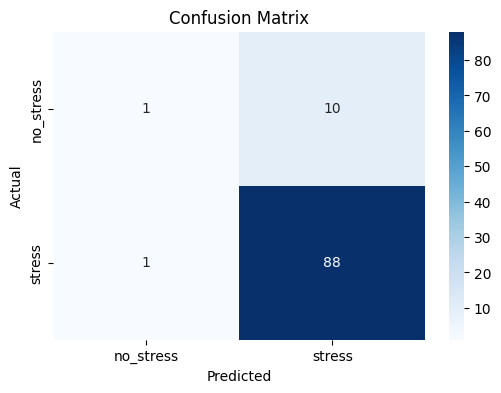

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Predict on test set
y_pred = clf.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no_stress','stress'], yticklabels=['no_stress','stress'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


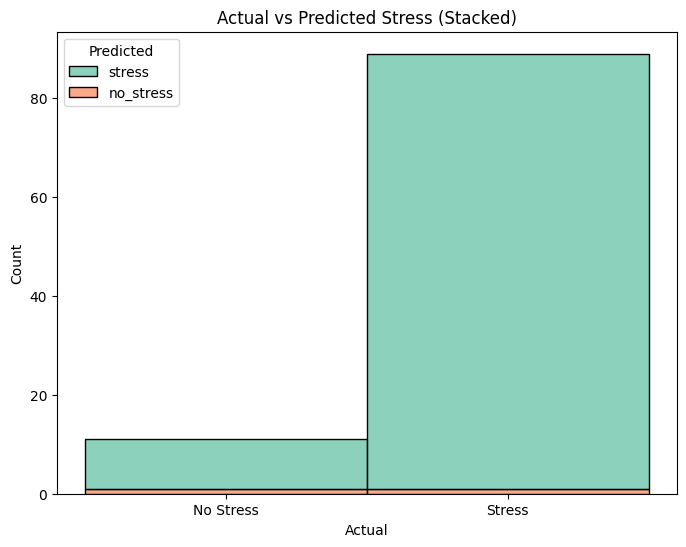

In [26]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(8,6))
sns.histplot(data=comparison_df, x="Actual", hue="Predicted", multiple="stack", palette="Set2")
plt.xticks([0,1], ['No Stress','Stress'])
plt.title("Actual vs Predicted Stress (Stacked)")
plt.ylabel("Count")
plt.show()


In [25]:
print("Trained model and scaler saved successfully.")

Trained model and scaler saved successfully.
